<!-- launch-badges -->
<a href="https://colab.research.google.com/github/laban254/ml-for-infrastructure/blob/main/03_machine_learning/scikit-learn/ensemble-methods/boosting.ipynb" target="_blank"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
&nbsp;
<a href="https://mybinder.org/v2/gh/laban254/ml-for-infrastructure/main?urlpath=lab/tree/03_machine_learning/scikit-learn/ensemble-methods/boosting.ipynb" target="_blank"><img src="https://mybinder.org/badge_logo.svg" alt="Open in Binder"/></a>

> ▶️ **Run this notebook live** — no install needed. Click a badge above to open it in a free cloud runtime.

# Ensemble Methods: Boosting

## Context
While *Bagging* (like Random Forest) trains many independent models in parallel and averages them, **Boosting** trains models **sequentially**. 

In Boosting, each new model looks at the mistakes made by the previous model and tries specifically to correct them. It turns a sequence of "weak learners" (like very shallow decision trees) into a single "strong learner".

In SRE, Boosting algorithms are a common go-to for tabular telemetry data tasks, like predicting Database Locks or SLA breaches, because they can be very accurate. In production, teams usually reach for optimized libraries like **XGBoost** or **LightGBM** for this. This notebook sticks to scikit-learn's built-in `GradientBoostingClassifier` instead, so we can learn the core boosting concept without pulling in an extra dependency.

## Objectives
- Generate a challenging SRE dataset: Predicting SLA Breaches based on Latency, Retries, and Error Rates.
- Train an **AdaBoost (Adaptive Boosting)** model.
- Train a **Gradient Boosting** model.
- Compare and contrast the two.

## Expected Outcome
- Working AdaBoost and Gradient Boosting classifiers trained on the same SLA breach data, with a bar chart comparing their test accuracy.
- An understanding of *how* each algorithm corrects prior mistakes (reweighting vs. fitting residuals) — not just which one happens to score higher on this particular dataset.</cell id="084d76b5">


In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

### 1. Generating SLA Breach Data
Predicting if an API SLA (Service Level Agreement) will breach based on current telemetry.

In [2]:
np.random.seed(42)
n_samples = 1000

X = pd.DataFrame({
    'P99_Latency_ms': np.random.normal(500, 200, n_samples),
    'Error_Rate_pct': np.random.normal(1.5, 1.0, n_samples),
    'Retry_Count': np.random.poisson(lam=5, size=n_samples)
})

# Complex combination leading to an SLA breach (1)
y = ((X['P99_Latency_ms'] > 750) | ((X['Error_Rate_pct'] > 2.5) & (X['Retry_Count'] > 8))).astype(int)

# Inject some noise to make it harder
noise_idx = np.random.choice(n_samples, size=50, replace=False)
y[noise_idx] = 1 - y[noise_idx]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

### 2. AdaBoost (Adaptive Boosting)
AdaBoost uses "Decision Stumps" (decision trees with only 1 split, e.g., `if Latency > 750: Breach else Normal`).
After the first stump is trained, it heavily weights the specific data points that it got wrong. The next stump focuses specifically on those hard weights. This repeats, and the final model is a weighted sum.

In [3]:
adaboost = AdaBoostClassifier(n_estimators=50, random_state=42)
adaboost.fit(X_train, y_train)

ada_pred = adaboost.predict(X_test)
print("AdaBoost Testing Accuracy: {:.2f}%".format(accuracy_score(y_test, ada_pred)*100))

AdaBoost Testing Accuracy: 94.67%


### 3. Gradient Boosting
Gradient Boosting also builds trees sequentially. However, instead of simply weighting misclassified points, the next tree tries to predict the **residual error** (the mathematical difference between the prediction and the actual value) of the previous tree using Gradient Descent.

It's a more flexible framework than AdaBoost — arbitrary loss functions, finer control over tree depth, learning rate, and regularization — but flexibility doesn't automatically mean a higher score on every dataset. See the actual comparison below.

In [4]:
# learning_rate controls how strongly each successive tree tries to correct the errors of the precursor.
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)
print("Gradient Boosting Testing Accuracy: {:.2f}%".format(accuracy_score(y_test, gb_pred)*100))

Gradient Boosting Testing Accuracy: 94.00%


### 4. Visual Comparison: AdaBoost vs. Gradient Boosting
A quick side-by-side of test accuracy for both models on this dataset.

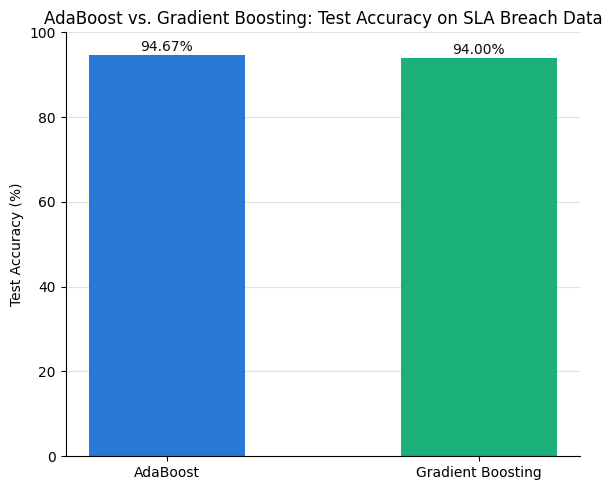

In [5]:
model_names = ['AdaBoost', 'Gradient Boosting']
accuracies = [
    accuracy_score(y_test, ada_pred) * 100,
    accuracy_score(y_test, gb_pred) * 100,
]
colors = ['#2a78d6', '#1baf7a']

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(model_names, accuracies, color=colors, width=0.5)

for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}%', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=10, color='#0b0b0b')

ax.set_ylabel('Test Accuracy (%)')
ax.set_title('AdaBoost vs. Gradient Boosting: Test Accuracy on SLA Breach Data')
ax.set_ylim(0, 100)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', color='#e1e0d9', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

### Summary Comparison

- **AdaBoost:** 
  - Focuses on misclassified samples by increasing their weight.
  - Simpler, but can be severely derailed by heavy noise/outliers (because it will obsess over trying to fix an unfixable outlier).
  - **In this run, AdaBoost scored 94.67% vs. Gradient Boosting's 94.00%** on the test set — a reminder that the more sophisticated algorithm doesn't automatically win on every dataset.
- **Gradient Boosting:** 
  - Focuses on minimizing the loss function (residuals) via gradient descent.
  - A more flexible framework than AdaBoost (arbitrary loss functions, finer control over depth/learning rate/regularization). That extra flexibility tends to pay off more on larger, higher-dimensional, or noisier datasets — this notebook's dataset is relatively small and low-dimensional, which is likely why AdaBoost edged it out here.
  - Very prone to overfitting if `n_estimators` is too high or `learning_rate` is not tuned properly.
- **Takeaway:** Always compare algorithms on your actual data instead of assuming the fancier one wins by default. Production-grade libraries like XGBoost/LightGBM add extra regularization and tuning knobs that often help Gradient Boosting variants pull ahead in practice, but that's a separate, empirical claim — not something to assume from theory alone.